# FASE 1: Carga y preparación del dataset

**Proyecto:** Sistema de alerta temprana de accidentes de tránsito en Cuenca mediante una Red Neuronal Artificial.

En esta fase se carga el dataset, se revisa su estructura, se limpian los datos y se crea una tabla preparada para calcular el riesgo histórico de accidentes. El objetivo ya no es predecir la severidad por víctimas, sino preparar la información para estimar la probabilidad de ocurrencia de accidentes según parroquia, zona, fecha y hora.

## 1. Importación de librerías
Aquí se cargan las librerías necesarias para trabajar con datos, hacer cálculos y crear gráficos básicos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pickle

## 2. Carga del dataset
En este paso se carga el archivo de accidentes de tránsito de Cuenca en un DataFrame para poder analizarlo y prepararlo.

In [2]:
# Cargar el dataset.
# El código intenta leer primero el archivo nuevo y luego el nombre original.

archivos_posibles = ["Dataset_Accidentes_Cuenca_2025.xlsx"]

archivo_dataset = None
for archivo in archivos_posibles:
    if Path(archivo).exists():
        archivo_dataset = archivo
        break

if archivo_dataset is None:
    raise FileNotFoundError(
        "No se encontró el dataset. Coloca el archivo Excel en la misma carpeta del notebook."
    )

print("Archivo cargado:", archivo_dataset)
dataframe = pd.read_excel(archivo_dataset)
dataframe.head()

Archivo cargado: Dataset_Accidentes_Cuenca_2025.xlsx


,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO
0,2024-01-01 00:00:00,15:34:59.952000,CUENCA,MOLLETURO,RURAL,-2.766635,-79.404454,RED VIAL E 582 KM 65 APROXIMADAMENTE SENTIDO ...,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,SI
1,2024-01-01 00:00:00,21:09:59.962000,CUENCA,SAYAUSI,RURAL,-2.802869,-79.158422,SE ENCUENTRA UBICADO RED ESTATAL E-582 SENTIDO...,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,CAMIONETA,3,0,SI
2,2024-01-03 00:00:00,08:15:00.086000,CUENCA,TARQUI (CUENCA),RURAL,-2.974194,-79.047028,RED VIAL E 35 KM 6,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,ESPECIAL,3,0,NO
3,2024-01-05 00:00:00,21:39:59.933000,CUENCA,BAÑOS (CUENCA),RURAL,-2.940667,-79.046417,RED VIAL E 35 KM 1.5 APROXIMADAMENTE.,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,NO
4,2024-01-06 00:00:00,19:59:59.971000,CUENCA,TARQUI (CUENCA),RURAL,-3.035944,-79.041639,RED VIAL E 35 KM 13 APROXIMADAMENTE.,CHOQUE POSTERIOR,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,AUTOMÓVIL,1,0,NO


## 3. Visualización inicial de los datos
Permite revisar las primeras, últimas y algunas filas aleatorias del dataset para entender cómo viene organizada la información.

In [3]:
dataframe.head()

,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO
0,2024-01-01 00:00:00,15:34:59.952000,CUENCA,MOLLETURO,RURAL,-2.766635,-79.404454,RED VIAL E 582 KM 65 APROXIMADAMENTE SENTIDO ...,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,SI
1,2024-01-01 00:00:00,21:09:59.962000,CUENCA,SAYAUSI,RURAL,-2.802869,-79.158422,SE ENCUENTRA UBICADO RED ESTATAL E-582 SENTIDO...,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,CAMIONETA,3,0,SI
2,2024-01-03 00:00:00,08:15:00.086000,CUENCA,TARQUI (CUENCA),RURAL,-2.974194,-79.047028,RED VIAL E 35 KM 6,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,ESPECIAL,3,0,NO
3,2024-01-05 00:00:00,21:39:59.933000,CUENCA,BAÑOS (CUENCA),RURAL,-2.940667,-79.046417,RED VIAL E 35 KM 1.5 APROXIMADAMENTE.,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,NO
4,2024-01-06 00:00:00,19:59:59.971000,CUENCA,TARQUI (CUENCA),RURAL,-3.035944,-79.041639,RED VIAL E 35 KM 13 APROXIMADAMENTE.,CHOQUE POSTERIOR,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,AUTOMÓVIL,1,0,NO


In [4]:
dataframe.tail()

,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO
1609,2025-12-26 00:00:00,14:56:00,CUENCA,TARQUI (CUENCA),RURAL,-3.016972,-79.040139,RED VIAL E 59 KM 11+500 APROX.,ROZAMIENTOS,NO GUARDAR LA DISTANCIA LATERAL MÍNIMA DE SEGU...,AUTOMÓVIL,0,0,NO
1610,2025-12-26 00:00:00,20:40:00,CUENCA,TARQUI (CUENCA),RURAL,-3.009750,-79.039583,RED VIAL E 59 KM 10+300 APROX.,ROZAMIENTOS,NO GUARDAR LA DISTANCIA LATERAL MÍNIMA DE SEGU...,CAMIONETA,0,0,NO
1611,2025-12-27 00:00:00,03:30:00,CUENCA,MOLLETURO,RURAL,-2.613611,-79.470556,E582 KM 107,ATROPELLOS,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,NO IDENTIFICADO,1,0,NO
1612,2025-12-28 00:00:00,07:05:00,CUENCA,TARQUI (CUENCA),RURAL,-2.977725,-79.047693,RED VIAL E 35 KM 8. FERRETERIA REYNA DEL CISNE,CHOQUE FRONTAL,CONDUCIR EN SENTIDO CONTRARIO A LA VÍA NORMAL ...,AUTOMÓVIL,0,0,NO
1613,2025-12-30 00:00:00,19:10:00,CUENCA,TARQUI (CUENCA),RURAL,-2.997425,-79.046564,SE ENCUENTRA UBICADO EN LA RED VIAL E-59 SENTI...,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,MOTOCICLETA,0,1,NO


In [5]:
dataframe.sample(5)

,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO
863,2024-09-30 00:00:00,18:41:00,CUENCA,CUENCA,URBANA,-2.883016,-79.008216,CAMINO A LAZARETO Y ABELARDO J ANDRADE,ESTRELLAMIENTOS,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,AUTOMÓVIL,2,0,NO
789,2024-09-12 00:00:00,15:53:00,CUENCA,CUENCA,URBANA,-2.916383,-78.997476,24 DE MAYO Y LOS CHUGOS,CHOQUE LATERAL,NO CEDER EL DERECHO DE VÍA O PREFERENCIA DE PA...,MOTOCICLETA,1,0,NO
844,2024-09-24 00:00:00,23:27:00,CUENCA,CUENCA,URBANA,-2.893041,-79.003163,LUIS CORDERO Y ANTONIO VEGA MUÑOZ,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,NO IDENTIFICADO,2,0,NO
356,2024-05-03 00:00:00,01:02:00,CUENCA,CUENCA,URBANA,-2.910629,-78.995637,12 DE ABRIL Y HUAYNA CAPAC,ESTRELLAMIENTOS,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,AUTOMÓVIL,0,0,SI
790,2024-09-12 00:00:00,20:20:00,CUENCA,CUENCA,URBANA,-2.891441,-78.993702,AV. GIL RAMIREZ DÁVALOS DEL CHORRO,ATROPELLOS,PEATÓN QUE CRUZA LA CALZADA SIN RESPETAR LA SE...,CAMIONETA,1,0,NO


## 4. Información general del dataset
Ayuda a conocer cuántas filas y columnas tiene el dataset, qué tipo de datos contiene cada columna y si existen valores vacíos.

In [6]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FECHA               1614 non-null   object 
 1   HORA                1614 non-null   object 
 2   CANTON              1614 non-null   object 
 3   PARROQUIA           1614 non-null   object 
 4   ZONA                1614 non-null   object 
 5   LATITUD_Y           1614 non-null   float64
 6   LONGITUD_X          1614 non-null   float64
 7   DIRECCION           1614 non-null   object 
 8   TIPO_DE_SINIESTRO   1614 non-null   object 
 9   CAUSA_PROBABLE      1614 non-null   object 
 10  TIPO_DE_VEHICULO_1  1614 non-null   object 
 11  LESIONADOS          1614 non-null   int64  
 12  FALLECIDOS          1614 non-null   int64  
 13  FERIADO             1614 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 176.7+ KB


In [7]:
dataframe.shape

(1614, 14)

In [8]:
dataframe.columns

Index(['FECHA', 'HORA', 'CANTON', 'PARROQUIA', 'ZONA', 'LATITUD_Y',
       'LONGITUD_X', 'DIRECCION', 'TIPO_DE_SINIESTRO', 'CAUSA_PROBABLE',
       'TIPO_DE_VEHICULO_1', 'LESIONADOS', 'FALLECIDOS', 'FERIADO'],
      dtype='object')

## 5. Estadísticas generales
Muestra un resumen general de las variables numéricas y categóricas. Sirve para detectar valores extremos, categorías repetidas y posibles errores.

In [9]:
dataframe.describe(include="all")

,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO
count,1614,1614,1614,1614,1614,1.614000e+03,1614.000000,1614,1614,1614,1614,1614.000000,1614.000000,1614
unique,556,1163,1,22,2,NaN,NaN,1499,13,26,11,NaN,NaN,2
top,2024-07-26 00:00:00,12:58:00,CUENCA,CUENCA,URBANA,NaN,NaN,PANAMERICANA NORTE Y SN,CHOQUE LATERAL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,AUTOMÓVIL,NaN,NaN,NO
freq,10,9,1614,1083,1112,NaN,NaN,5,524,426,455,NaN,NaN,1461
mean,NaN,NaN,NaN,NaN,NaN,1.057257e+06,-79.061456,NaN,NaN,NaN,NaN,0.838910,0.055762,NaN
std,NaN,NaN,NaN,NaN,NaN,4.247501e+07,0.249905,NaN,NaN,NaN,NaN,1.001585,0.291416,NaN
min,NaN,NaN,NaN,NaN,NaN,-3.675139e+00,-80.970751,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,-2.914622e+00,-79.043921,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,-2.896843e+00,-79.013428,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,-2.878284e+00,-78.987484,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN


## 6. Verificación de valores nulos
Este paso permite saber si existen datos faltantes en alguna columna. Es importante porque los valores vacíos pueden afectar la preparación del dataset.

In [10]:
dataframe.isnull().sum()

FECHA                 0
HORA                  0
CANTON                0
PARROQUIA             0
ZONA                  0
LATITUD_Y             0
LONGITUD_X            0
DIRECCION             0
TIPO_DE_SINIESTRO     0
CAUSA_PROBABLE        0
TIPO_DE_VEHICULO_1    0
LESIONADOS            0
FALLECIDOS            0
FERIADO               0
dtype: int64

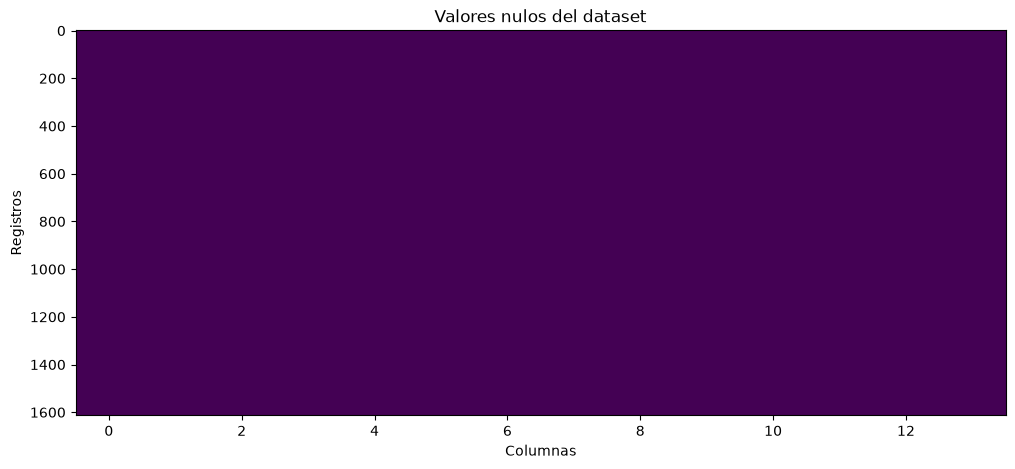

In [11]:
plt.figure(figsize=(12, 5))
plt.imshow(dataframe.isnull(), aspect="auto")
plt.title("Valores nulos del dataset")
plt.xlabel("Columnas")
plt.ylabel("Registros")
plt.show()

El mapa de calor muestra que todas las variables contienen información completa y no presentan valores faltantes. Esto indica que el conjunto de datos no requiere un proceso adicional de imputación antes del entrenamiento del modelo.

## 7. Limpieza básica de columnas de texto
Sirve para unificar los textos del dataset. Por ejemplo, evita que una misma parroquia aparezca escrita de formas diferentes por espacios o uso de minúsculas.

In [12]:
columnas_texto = [
    "CANTON",
    "PARROQUIA",
    "ZONA",
    "DIRECCION",
    "TIPO_DE_SINIESTRO",
    "CAUSA_PROBABLE",
    "TIPO_DE_VEHICULO_1",
    "FERIADO"
]

for columna in columnas_texto:
    if columna in dataframe.columns:
        dataframe[columna] = dataframe[columna].astype(str).str.strip().str.upper()

dataframe[columnas_texto].head()

,CANTON,PARROQUIA,ZONA,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,FERIADO
0,CUENCA,MOLLETURO,RURAL,RED VIAL E 582 KM 65 APROXIMADAMENTE SENTIDO ...,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,SI
1,CUENCA,SAYAUSI,RURAL,SE ENCUENTRA UBICADO RED ESTATAL E-582 SENTIDO...,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,CAMIONETA,SI
2,CUENCA,TARQUI (CUENCA),RURAL,RED VIAL E 35 KM 6,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,ESPECIAL,NO
3,CUENCA,BAÑOS (CUENCA),RURAL,RED VIAL E 35 KM 1.5 APROXIMADAMENTE.,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,NO
4,CUENCA,TARQUI (CUENCA),RURAL,RED VIAL E 35 KM 13 APROXIMADAMENTE.,CHOQUE POSTERIOR,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,AUTOMÓVIL,NO


## 8. Conversión de fecha y creación de variables temporales
Este paso convierte la fecha en un formato que Python pueda manejar. Luego se extraen variables como mes, día y día de la semana, que ayudarán a identificar patrones temporales de accidentes.

In [13]:
dataframe["FECHA"] = pd.to_datetime(dataframe["FECHA"], errors="coerce")

dataframe["MES"] = dataframe["FECHA"].dt.month
dataframe["DIA"] = dataframe["FECHA"].dt.day
dataframe["DIA_SEMANA"] = dataframe["FECHA"].dt.dayofweek

dataframe[["FECHA", "MES", "DIA", "DIA_SEMANA"]].head()

,FECHA,MES,DIA,DIA_SEMANA
0,2024-01-01,1,1,0
1,2024-01-01,1,1,0
2,2024-01-03,1,3,2
3,2024-01-05,1,5,4
4,2024-01-06,1,6,5


## 9. Conversión de la hora
Sirve para transformar la hora del accidente en un número entero. Esto facilita analizar en qué horarios se concentran más accidentes.

In [14]:
def obtener_hora(valor):
    if pd.isnull(valor):
        return np.nan
    
    if isinstance(valor, time):
        return valor.hour
    
    try:
        hora = pd.to_datetime(str(valor), errors="coerce")
        return hora.hour
    except Exception:
        return np.nan

dataframe["HORA_NUM"] = dataframe["HORA"].apply(obtener_hora)

dataframe[["HORA", "HORA_NUM"]].head()

,HORA,HORA_NUM
0,15:34:59.952000,15
1,21:09:59.962000,21
2,08:15:00.086000,8
3,21:39:59.933000,21
4,19:59:59.971000,19


La columna HORA_NUM representa la hora del accidente en formato numérico. 
Esta variable será útil para detectar horarios de mayor riesgo durante el día o la noche.

## 10. Creación de variable de impacto histórico
Aquí se crea TOTAL_VICTIMAS, pero ya no se usa como objetivo principal. Solo sirve como apoyo estadístico para conocer el impacto de los accidentes registrados.

In [15]:
dataframe["LESIONADOS"] = pd.to_numeric(
    dataframe["LESIONADOS"], errors="coerce"
).fillna(0).astype(int)

dataframe["FALLECIDOS"] = pd.to_numeric(
    dataframe["FALLECIDOS"], errors="coerce"
).fillna(0).astype(int)

dataframe["TOTAL_VICTIMAS"] = dataframe["LESIONADOS"] + dataframe["FALLECIDOS"]

print("Total lesionados:", dataframe["LESIONADOS"].sum())
print("Total fallecidos:", dataframe["FALLECIDOS"].sum())
print("Total víctimas:", dataframe["TOTAL_VICTIMAS"].sum())

dataframe[["LESIONADOS", "FALLECIDOS", "TOTAL_VICTIMAS"]].head()

Total lesionados: 1354
Total fallecidos: 90
Total víctimas: 1444


,LESIONADOS,FALLECIDOS,TOTAL_VICTIMAS
0,0,0,0
1,3,0,3
2,3,0,3
3,0,0,0
4,1,0,1


La columna TOTAL_VICTIMAS se usa como variable de impacto histórico. 
No será la variable objetivo del modelo, porque el proyecto no busca predecir cuántas víctimas tendrá un accidente. 
El objetivo principal es estimar el riesgo de que ocurra un accidente según la parroquia, zona, fecha y hora.

## 11. Eliminación de registros incompletos en variables clave
Este paso elimina los registros que no tienen datos importantes para calcular el riesgo, como fecha, hora, parroquia o zona.

In [16]:
columnas_clave = [
    "FECHA",
    "MES",
    "DIA",
    "DIA_SEMANA",
    "HORA_NUM",
    "PARROQUIA",
    "ZONA"
]

dataframe_limpio = dataframe.dropna(subset=columnas_clave).copy()

print("Filas antes de limpiar:", dataframe.shape[0])
print("Filas después de limpiar:", dataframe_limpio.shape[0])

dataframe_limpio.head()

Filas antes de limpiar: 1614
Filas después de limpiar: 1614


,FECHA,HORA,CANTON,PARROQUIA,ZONA,LATITUD_Y,LONGITUD_X,DIRECCION,TIPO_DE_SINIESTRO,CAUSA_PROBABLE,TIPO_DE_VEHICULO_1,LESIONADOS,FALLECIDOS,FERIADO,MES,DIA,DIA_SEMANA,HORA_NUM,TOTAL_VICTIMAS
0,2024-01-01,15:34:59.952000,CUENCA,MOLLETURO,RURAL,-2.766635,-79.404454,RED VIAL E 582 KM 65 APROXIMADAMENTE SENTIDO ...,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,SI,1,1,0,15,0
1,2024-01-01,21:09:59.962000,CUENCA,SAYAUSI,RURAL,-2.802869,-79.158422,SE ENCUENTRA UBICADO RED ESTATAL E-582 SENTIDO...,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,CAMIONETA,3,0,SI,1,1,0,21,3
2,2024-01-03,08:15:00.086000,CUENCA,TARQUI (CUENCA),RURAL,-2.974194,-79.047028,RED VIAL E 35 KM 6,PÉRDIDA DE CARRIL,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,ESPECIAL,3,0,NO,1,3,2,8,3
3,2024-01-05,21:39:59.933000,CUENCA,BAÑOS (CUENCA),RURAL,-2.940667,-79.046417,RED VIAL E 35 KM 1.5 APROXIMADAMENTE.,CHOQUE LATERAL,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,AUTOMÓVIL,0,0,NO,1,5,4,21,0
4,2024-01-06,19:59:59.971000,CUENCA,TARQUI (CUENCA),RURAL,-3.035944,-79.041639,RED VIAL E 35 KM 13 APROXIMADAMENTE.,CHOQUE POSTERIOR,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,AUTOMÓVIL,1,0,NO,1,6,5,19,1


Se eliminaron los registros incompletos en las variables principales. 
Esto permite trabajar con una base más limpia y adecuada para construir el dataset de riesgo.

## 12. Construcción de la tabla de riesgo histórico
Este es el paso más importante. Aquí se agrupan los accidentes por parroquia, zona, mes, día de la semana y hora. Luego se cuenta cuántos accidentes ocurrieron en cada combinación.


In [17]:
def moda_segura(serie):
    moda = serie.mode(dropna=True)
    
    if len(moda) == 0:
        return np.nan
    
    return moda.iloc[0]

In [18]:
columnas_agrupacion = [
    "PARROQUIA",
    "ZONA",
    "MES",
    "DIA_SEMANA",
    "HORA_NUM"
]

dataset_riesgo = (
    dataframe_limpio
    .groupby(columnas_agrupacion)
    .agg(
        ACCIDENTES=("FECHA", "count"),
        PROM_LESIONADOS=("LESIONADOS", "mean"),
        PROM_FALLECIDOS=("FALLECIDOS", "mean"),
        PROM_TOTAL_VICTIMAS=("TOTAL_VICTIMAS", "mean"),
        CAUSA_MAS_FRECUENTE=("CAUSA_PROBABLE", moda_segura),
        TIPO_SINIESTRO_MAS_FRECUENTE=("TIPO_DE_SINIESTRO", moda_segura),
        TIPO_VEHICULO_MAS_FRECUENTE=("TIPO_DE_VEHICULO_1", moda_segura),
        LATITUD_PROM=("LATITUD_Y", "mean"),
        LONGITUD_PROM=("LONGITUD_X", "mean")
    )
    .reset_index()
)

dataset_riesgo.head()

,PARROQUIA,ZONA,MES,DIA_SEMANA,HORA_NUM,ACCIDENTES,PROM_LESIONADOS,PROM_FALLECIDOS,PROM_TOTAL_VICTIMAS,CAUSA_MAS_FRECUENTE,TIPO_SINIESTRO_MAS_FRECUENTE,TIPO_VEHICULO_MAS_FRECUENTE,LATITUD_PROM,LONGITUD_PROM
0,BAÑOS (CUENCA),RURAL,1,1,7,1,0.0,0.0,0.0,CONDUCIR EN SENTIDO CONTRARIO A LA VÍA NORMAL ...,CHOQUE FRONTAL,CAMIONETA,-2.920229,-79.066367
1,BAÑOS (CUENCA),RURAL,1,2,19,1,3.0,0.0,3.0,CONDUCIR EN SENTIDO CONTRARIO A LA VÍA NORMAL ...,CHOQUE FRONTAL,AUTOMÓVIL,-2.941882,-79.045685
2,BAÑOS (CUENCA),RURAL,1,4,21,1,0.0,0.0,0.0,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,CHOQUE LATERAL,AUTOMÓVIL,-2.940667,-79.046417
3,BAÑOS (CUENCA),RURAL,1,5,10,1,0.0,0.0,0.0,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,CHOQUE LATERAL,AUTOMÓVIL,-2.952250,-79.048444
4,BAÑOS (CUENCA),RURAL,2,1,12,1,1.0,0.0,1.0,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,OTROS,NO IDENTIFICADO,-2.941439,-79.048179


Cada fila de esta nueva tabla representa una combinación de parroquia, zona, mes, día de la semana y hora. 
La columna ACCIDENTES indica cuántos siniestros ocurrieron históricamente en esa combinación. 
Esta frecuencia será la base para calcular el nivel de riesgo.

## 13. Cálculo del porcentaje de riesgo
Convierte la cantidad de accidentes en un porcentaje entre 0 % y 100 %. Mientras más accidentes tenga una combinación, mayor será su riesgo.

In [19]:
max_accidentes = dataset_riesgo["ACCIDENTES"].max()

dataset_riesgo["RIESGO_PORC"] = (
    dataset_riesgo["ACCIDENTES"] / max_accidentes * 100
).round(2)

dataset_riesgo[["ACCIDENTES", "RIESGO_PORC"]].head()

,ACCIDENTES,RIESGO_PORC
0,1,20.0
1,1,20.0
2,1,20.0
3,1,20.0
4,1,20.0


El porcentaje de riesgo se calcula tomando como referencia la combinación con mayor número de accidentes. 
Así, el valor más alto queda cercano al 100 %, mientras que las combinaciones con menos accidentes tienen un porcentaje menor.

## 14. Clasificación del nivel de riesgo
Convierte el porcentaje de riesgo en una categoría más fácil de interpretar: bajo, medio o alto.

In [20]:
def clasificar_nivel_riesgo(riesgo):
    if riesgo >= 60:
        return "ALTO"
    elif riesgo >= 40:
        return "MEDIO"
    else:
        return "BAJO"

dataset_riesgo["NIVEL_RIESGO"] = dataset_riesgo["RIESGO_PORC"].apply(clasificar_nivel_riesgo)

dataset_riesgo[["ACCIDENTES", "RIESGO_PORC", "NIVEL_RIESGO"]].head()

,ACCIDENTES,RIESGO_PORC,NIVEL_RIESGO
0,1,20.0,BAJO
1,1,20.0,BAJO
2,1,20.0,BAJO
3,1,20.0,BAJO
4,1,20.0,BAJO


La variable NIVEL_RIESGO permite interpretar el porcentaje de forma más sencilla. 
Aunque el modelo puede trabajar con el valor numérico de riesgo, la aplicación puede mostrarlo como Bajo, Medio o Alto.

## 15. Distribución del nivel de riesgo
Permite ver cuántas combinaciones fueron clasificadas como riesgo bajo, medio o alto.

In [21]:
dataset_riesgo["NIVEL_RIESGO"].value_counts()

NIVEL_RIESGO
BAJO     1104
MEDIO     175
ALTO       49
Name: count, dtype: int64

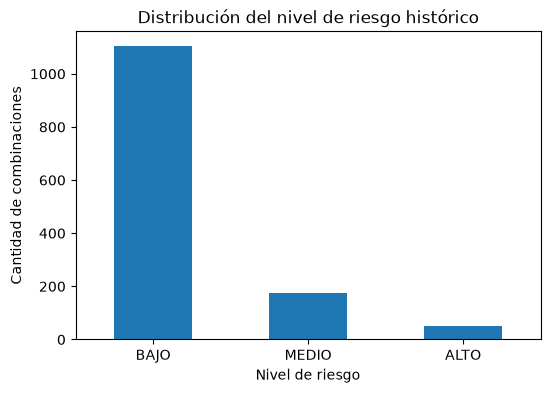

In [22]:
conteo_riesgo = dataset_riesgo["NIVEL_RIESGO"].value_counts().reindex(
    ["BAJO", "MEDIO", "ALTO"], fill_value=0
)

plt.figure(figsize=(6, 4))
conteo_riesgo.plot(kind="bar")
plt.title("Distribución del nivel de riesgo histórico")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de combinaciones")
plt.xticks(rotation=0)
plt.show()

Este gráfico ayuda a revisar cómo quedó distribuido el riesgo. 
Si existen demasiados registros en una sola categoría, puede ser necesario ajustar los rangos de clasificación.

## 16. Revisión del dataset final
Este paso revisa la estructura final del dataset que se usará en la siguiente fase.

In [23]:
dataset_riesgo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PARROQUIA                     1328 non-null   object 
 1   ZONA                          1328 non-null   object 
 2   MES                           1328 non-null   int32  
 3   DIA_SEMANA                    1328 non-null   int32  
 4   HORA_NUM                      1328 non-null   int64  
 5   ACCIDENTES                    1328 non-null   int64  
 6   PROM_LESIONADOS               1328 non-null   float64
 7   PROM_FALLECIDOS               1328 non-null   float64
 8   PROM_TOTAL_VICTIMAS           1328 non-null   float64
 9   CAUSA_MAS_FRECUENTE           1328 non-null   object 
 10  TIPO_SINIESTRO_MAS_FRECUENTE  1328 non-null   object 
 11  TIPO_VEHICULO_MAS_FRECUENTE   1328 non-null   object 
 12  LATITUD_PROM                  1328 non-null   float64
 13  LON

In [24]:
dataset_riesgo.describe(include="all")

,PARROQUIA,ZONA,MES,DIA_SEMANA,HORA_NUM,ACCIDENTES,PROM_LESIONADOS,PROM_FALLECIDOS,PROM_TOTAL_VICTIMAS,CAUSA_MAS_FRECUENTE,TIPO_SINIESTRO_MAS_FRECUENTE,TIPO_VEHICULO_MAS_FRECUENTE,LATITUD_PROM,LONGITUD_PROM,RIESGO_PORC,NIVEL_RIESGO
count,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328,1328,1328,1.328000e+03,1328.000000,1328.000000,1328
unique,22,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26,13,11,NaN,NaN,NaN,3
top,CUENCA,URBANA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,CHOQUE LATERAL,AUTOMÓVIL,NaN,NaN,NaN,BAJO
freq,805,834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381,436,415,NaN,NaN,NaN,1104
mean,NaN,NaN,6.699548,3.233434,12.965361,1.215361,0.846611,0.060203,0.906815,NaN,NaN,NaN,1.284950e+06,-79.063867,24.307229,NaN
std,NaN,NaN,3.432317,2.006702,6.413438,0.535413,0.995022,0.302430,1.056377,NaN,NaN,NaN,4.682591e+07,0.252266,10.708252,NaN
min,NaN,NaN,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,-3.551333e+00,-80.970751,20.000000,NaN
25%,NaN,NaN,4.000000,2.000000,8.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,-2.915567e+00,-79.046490,20.000000,NaN
50%,NaN,NaN,7.000000,3.000000,14.000000,1.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN,-2.896735e+00,-79.015508,20.000000,NaN
75%,NaN,NaN,10.000000,5.000000,18.000000,1.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN,-2.875055e+00,-78.990209,20.000000,NaN


In [25]:
dataset_riesgo.head(10)

,PARROQUIA,ZONA,MES,DIA_SEMANA,HORA_NUM,ACCIDENTES,PROM_LESIONADOS,PROM_FALLECIDOS,PROM_TOTAL_VICTIMAS,CAUSA_MAS_FRECUENTE,TIPO_SINIESTRO_MAS_FRECUENTE,TIPO_VEHICULO_MAS_FRECUENTE,LATITUD_PROM,LONGITUD_PROM,RIESGO_PORC,NIVEL_RIESGO
0,BAÑOS (CUENCA),RURAL,1,1,7,1,0.0,0.0,0.0,CONDUCIR EN SENTIDO CONTRARIO A LA VÍA NORMAL ...,CHOQUE FRONTAL,CAMIONETA,-2.920229,-79.066367,20.0,BAJO
1,BAÑOS (CUENCA),RURAL,1,2,19,1,3.0,0.0,3.0,CONDUCIR EN SENTIDO CONTRARIO A LA VÍA NORMAL ...,CHOQUE FRONTAL,AUTOMÓVIL,-2.941882,-79.045685,20.0,BAJO
2,BAÑOS (CUENCA),RURAL,1,4,21,1,0.0,0.0,0.0,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,CHOQUE LATERAL,AUTOMÓVIL,-2.940667,-79.046417,20.0,BAJO
3,BAÑOS (CUENCA),RURAL,1,5,10,1,0.0,0.0,0.0,NO RESPETAR LAS SEÑALES REGLAMENTARIAS DE TRÁN...,CHOQUE LATERAL,AUTOMÓVIL,-2.952250,-79.048444,20.0,BAJO
4,BAÑOS (CUENCA),RURAL,2,1,12,1,1.0,0.0,1.0,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,OTROS,NO IDENTIFICADO,-2.941439,-79.048179,20.0,BAJO
5,BAÑOS (CUENCA),RURAL,2,1,20,1,1.0,0.0,1.0,"CONDUCE BAJO LA INFLUENCIA DE ALCOHOL, SUSTANC...",CHOQUE FRONTAL,AUTOMÓVIL,-2.921718,-79.079933,20.0,BAJO
6,BAÑOS (CUENCA),RURAL,2,3,1,1,0.0,0.0,0.0,CONDUCIR DESATENTO A LAS CONDICIONES DE TRÁNSI...,PÉRDIDA DE CARRIL,CAMIÓN,-2.950666,-79.047555,20.0,BAJO
7,BAÑOS (CUENCA),RURAL,3,3,7,1,0.0,0.0,0.0,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,COLISIÓN,AUTOMÓVIL,-2.949889,-79.047194,20.0,BAJO
8,BAÑOS (CUENCA),RURAL,3,6,2,1,0.0,0.0,0.0,"CONDUCE BAJO LA INFLUENCIA DE ALCOHOL, SUSTANC...",CHOQUE LATERAL,VEHÍCULO DEPORTIVO UTILITARIO,-2.920433,-79.062729,20.0,BAJO
9,BAÑOS (CUENCA),RURAL,3,6,17,1,0.0,0.0,0.0,NO MANTENER LA DISTANCIA PRUDENCIAL CON RESPEC...,CHOQUE POSTERIOR,VEHÍCULO DEPORTIVO UTILITARIO,-2.948083,-79.047001,20.0,BAJO


In [26]:
# Exportar dataset_riesgo a CSV
output_path = "dataset_riesgo_cuenca.csv"
try:
    dataset_riesgo.to_csv(output_path, index=False)
    print(f"Exportado: {output_path}")
except NameError:
    print("Error: la variable 'dataset_riesgo' no está definida en el notebook. Ejecuta las celdas previas antes de exportar.")
except Exception as e:
    print("Error al exportar:", e)

Exportado: dataset_riesgo_cuenca.csv
